In [1]:
from pathlib import Path

import gffutils
import numpy as np
import polars as pl
from safetensors.torch import load_file
from scipy.stats import entropy
import seaborn as sns
from statannotations.Annotator import Annotator

import torch

# Data loading

In [2]:
basepath = Path("/no_backup/rg/itrujnara/infer_chromosome/tensors")

In [3]:
size = 2**20
stride = size - 8192
chr_size = 46709983

In [4]:
chunks = []

for start in range(0,chr_size,stride):
    end = start + size
    filename = f"ch38_chr21_{start}_{end}_probs.safetensors"
    try:
        chunk_probs = load_file(basepath / filename)["probs"]
        chunks.append(chunk_probs)
    except FileNotFoundError:
        print(filename + " not found")

ch38_chr21_0_1048576_probs.safetensors not found
ch38_chr21_1040384_2088960_probs.safetensors not found
ch38_chr21_2080768_3129344_probs.safetensors not found
ch38_chr21_3121152_4169728_probs.safetensors not found


In [5]:
chunks[0].shape

torch.Size([1040384, 4])

In [6]:
embedding = load_file(basepath / "ch38_chr21_10403840_11452416_embeddings.safetensors")["embeddings"]

In [7]:
embedding.shape

torch.Size([1040384, 4096])

In [8]:
probs = torch.cat(chunks)

In [9]:
probs.shape

torch.Size([42540255, 4])

In [10]:
ic = 2 - entropy(probs, axis=1, base=2)

In [11]:
ic.shape

(42540255,)

In [12]:
db = gffutils.FeatureDB("/users/cn/itrujnara/genomes-project/infer_chromosome/compare_gff/gencode.v48.chr21.db")

# Exploration

## IC track

In [13]:
ic.mean()

np.float32(0.5669044)

In [14]:
(ic > 1.).mean()

np.float64(0.2546861555014186)

In [15]:
(ic > 1.5).mean()

np.float64(0.13608075456999494)

In [16]:
(ic > 1.75).mean()

np.float64(0.07293016931844908)

<Axes: >

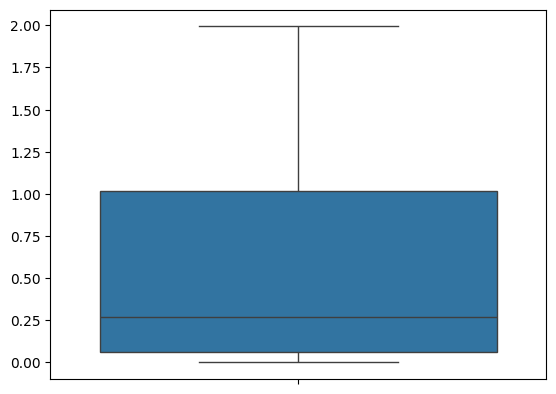

In [17]:
sns.boxplot(ic)

Text(0.5, 1.0, 'IC distribution for all positions')

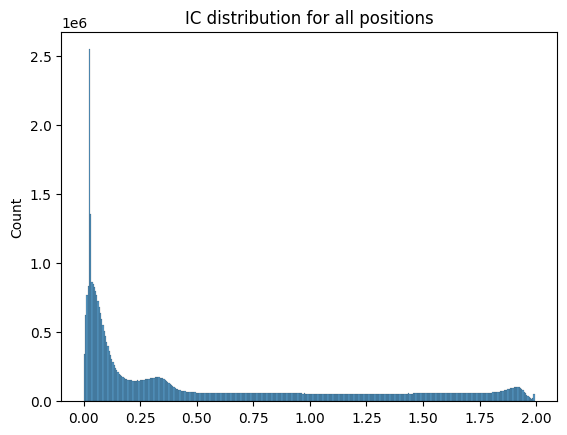

In [18]:
ax = sns.histplot(ic)

ax.set_title("IC distribution for all positions")

In [19]:
entropy([0.4,0.1,0.1,0.4], base=2)

np.float64(1.7219280948873625)

In [20]:
entropy([0.33,0.33,0.33,0], base=2)

np.float64(1.584962500721156)

## GFF

In [21]:
db.count_features_of_type("gene")

1134

In [22]:
gene_types = set()

for feature in db.all_features():
    for t in feature["gene_type"]:
        gene_types.add(t)

In [23]:
gene_types

{'IG_V_gene',
 'TEC',
 'artifact',
 'lncRNA',
 'miRNA',
 'misc_RNA',
 'processed_pseudogene',
 'protein_coding',
 'rRNA',
 'rRNA_pseudogene',
 'snRNA',
 'snoRNA',
 'transcribed_processed_pseudogene',
 'transcribed_unprocessed_pseudogene',
 'unprocessed_pseudogene'}

# Analysis

In [24]:
def get_feature_ics(gff_db, ics, feature_type, gene_type=None, exclude_type=None, offset=4169728):
    """Extract and concatenate the positions of the IC track spanned by a given GFF feature."""
    feature_ranges = []

    for feature in gff_db.features_of_type(feature_type, order_by=("start")):
        if gene_type is not None and gene_type not in feature["gene_type"]:
            continue
        if exclude_type is not None and exclude_type in feature["gene_type"]:
            continue
        feature_ranges.append((feature.start - offset, feature.end - offset))

    feature_ics = []

    for feature in feature_ranges:
        feature_ic = ic[feature[0]:feature[1]]
        feature_ics.append(feature_ic)

    return np.concatenate(feature_ics)

In [25]:
def get_feature_means(gff_db, ics, feature_type, gene_type=None, offset=4169728):
    """Extract and concatenate the mean ICs of GFF features of a given type."""
    feature_ranges = []

    for feature in gff_db.features_of_type(feature_type, order_by=("start")):
        if gene_type is not None and gene_type not in feature["gene_type"]:
            continue
        feature_ranges.append((feature.start - offset, feature.end - offset))

    feature_means = []

    for feature in feature_ranges:
        feature_mean = ic[feature[0]:feature[1]].mean()
        feature_means.append(feature_mean)

    return np.array(feature_means)

## Genes

In [26]:
gene_ics = get_feature_ics(db, ic, "gene")

In [27]:
gene_ics.mean()

np.float32(0.50602)

<Axes: >

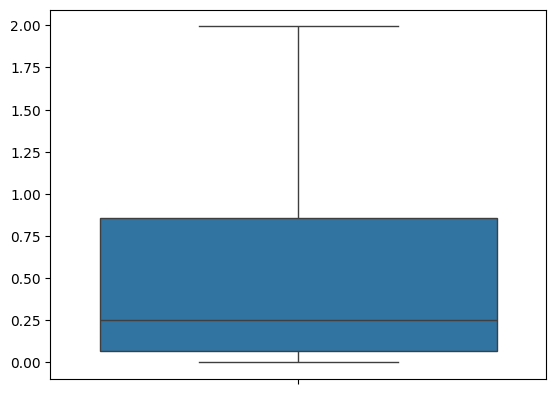

In [28]:
sns.boxplot(gene_ics)

In [29]:
pc_gene_ics = get_feature_ics(db, ic, "gene", "protein_coding")

In [30]:
pc_gene_ics.mean()

np.float32(0.49062768)

<Axes: >

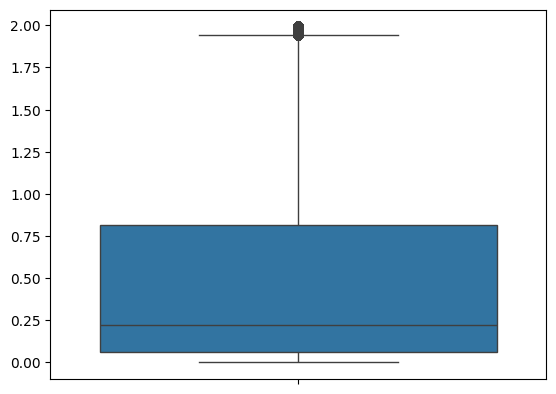

In [31]:
sns.boxplot(pc_gene_ics)

Text(0.5, 0, 'Information content')

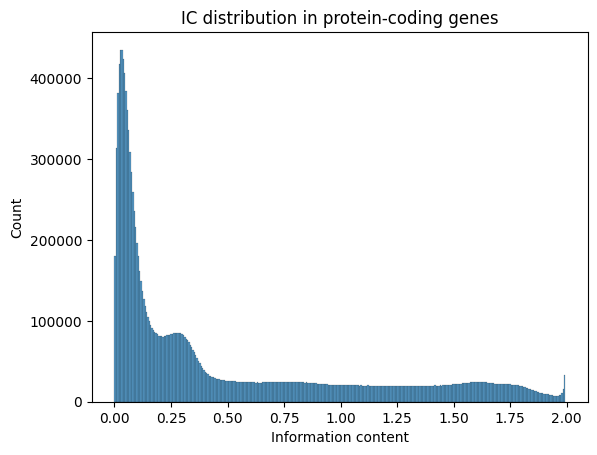

In [32]:
ax = sns.histplot(pc_gene_ics)

ax.set_title("IC distribution in protein-coding genes")
ax.set_xlabel("Information content")

In [33]:
def array_to_df(arr, group_name):
    return pl.DataFrame({"value": arr, "label": [group_name] * arr.shape[0]})

In [34]:
df_all = array_to_df(ic, "All positions")

In [35]:
df_genes = array_to_df(gene_ics, "All genes")

In [36]:
df_pc_genes = array_to_df(pc_gene_ics, "Protein-coding genes")

In [37]:
df_genes_vs_all = df_all.vstack(df_genes).vstack(df_pc_genes)

In [38]:
set(df_genes_vs_all["label"])

{'All genes', 'All positions', 'Protein-coding genes'}

Text(0, 0.5, 'Information content')

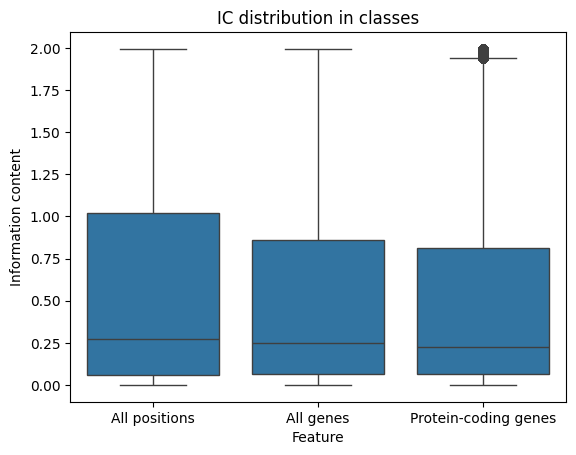

In [39]:
order = [""]

plot_params = {
    "data": df_genes_vs_all,
    "x": "label",
    "y": "value"
}

ax = sns.boxplot(**plot_params)

ax.set_title("IC distribution in classes")
ax.set_xlabel("Feature")
ax.set_ylabel("Information content")

## All exons

In [40]:
exon_ics = get_feature_ics(db, ic, "exon")

In [93]:
exon_ics.shape

(3927405,)

In [41]:
(exon_ics > 1.5).mean()

np.float64(0.2200073585484563)

Text(0.5, 0, 'Information content')

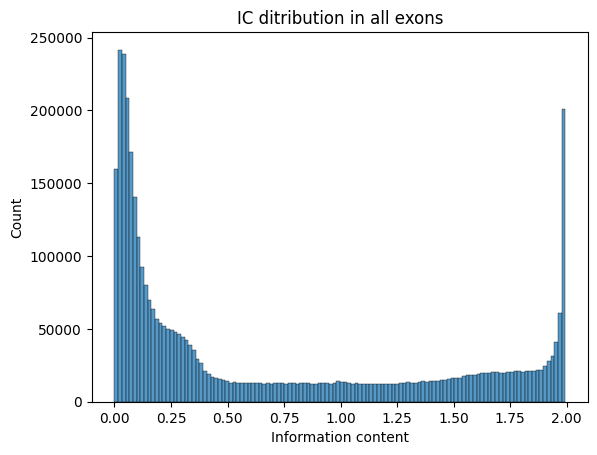

In [42]:
ax = sns.histplot(exon_ics)

ax.set_title("IC ditribution in all exons")
ax.set_xlabel("Information content")

In [43]:
exon_means = get_feature_means(db, ic, "exon")

<Axes: ylabel='Count'>

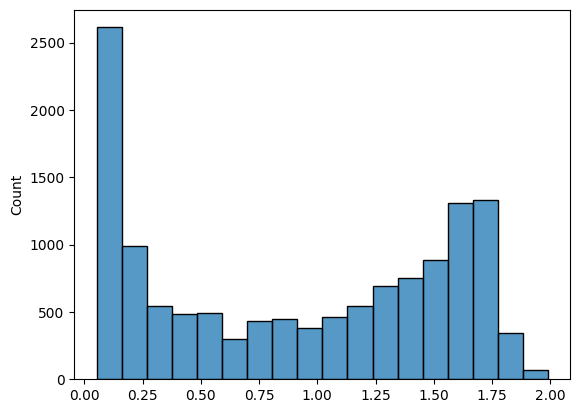

In [44]:
sns.histplot(exon_means)

## Protein-coding exons

In [45]:
pc_exon_ics = get_feature_ics(db, ic, "exon", "protein_coding")

In [46]:
pc_exon_ics.mean()

np.float32(0.8882963)

<Axes: >

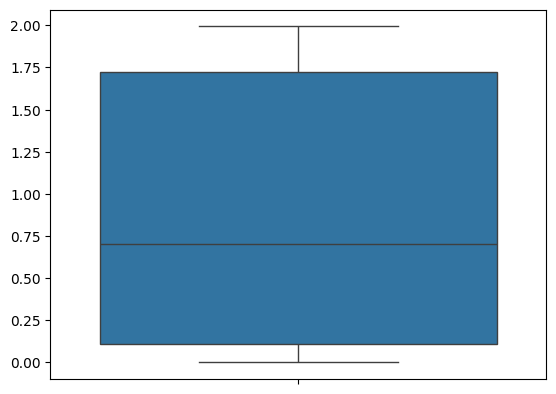

In [47]:
sns.boxplot(pc_exon_ics)

Text(0.5, 0, 'Information content')

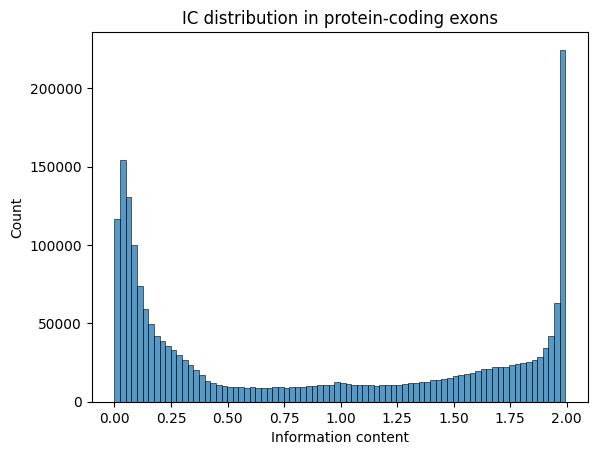

In [90]:
ax = sns.histplot(pc_exon_ics)

ax.set_title("IC distribution in protein-coding exons")
ax.set_xlabel("Information content")

In [49]:
pc_exon_means = get_feature_means(db, ic, "exon", "protein_coding")

<Axes: >

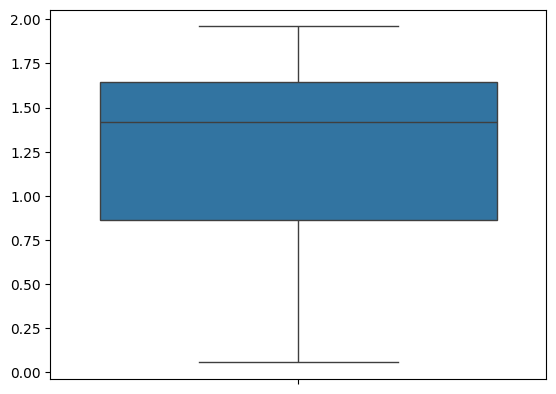

In [50]:
sns.boxplot(pc_exon_means)

<Axes: ylabel='Count'>

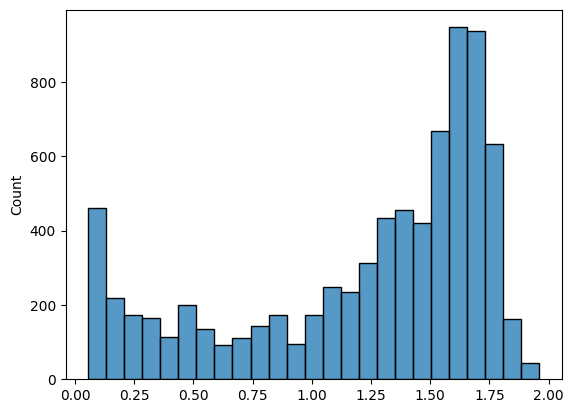

In [51]:
sns.histplot(pc_exon_means)

## Protein-coding CDS

In [52]:
cds_ics = get_feature_ics(db, ic, "CDS", "protein_coding")

In [94]:
cds_ics.shape

(152366,)

In [53]:
cds_ics.mean()

np.float32(1.3358622)

<Axes: >

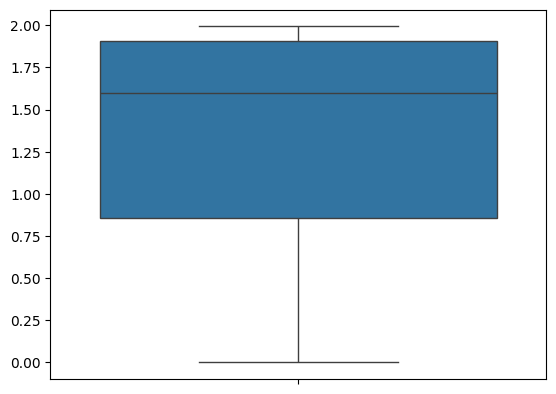

In [54]:
sns.boxplot(cds_ics)

Text(0.5, 1.0, 'IC distribution in protein-coding CDS')

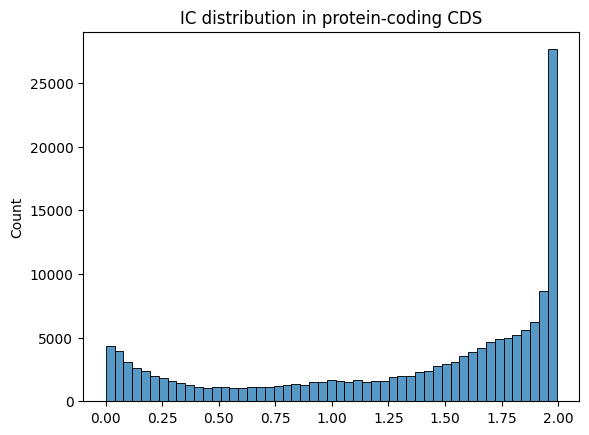

In [55]:
ax = sns.histplot(cds_ics)

ax.set_title("IC distribution in protein-coding CDS")

In [56]:
cds_means = get_feature_means(db, ic, "CDS", "protein_coding")

/tmp/13128792/ipykernel_941321/2659594678.py:13: RuntimeWarning: Mean of empty slice.
  feature_mean = ic[feature[0]:feature[1]].mean()
/users/cn/itrujnara/envs/venv_gpu/lib64/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


<Axes: >

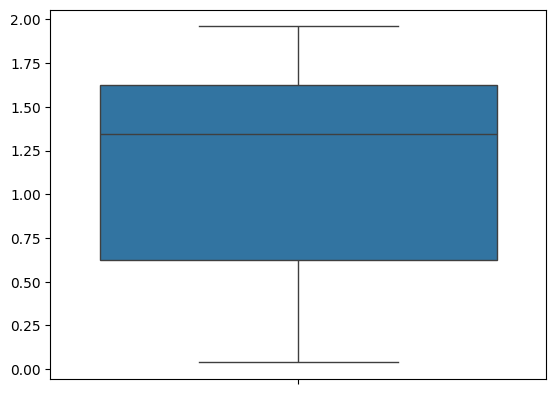

In [57]:
sns.boxplot(cds_means)

<Axes: ylabel='Count'>

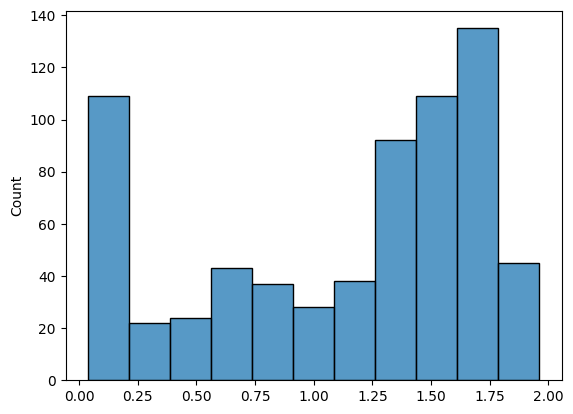

In [58]:
sns.histplot(cds_means)

## Non-protein exons

In [59]:
np_exon_ics = get_feature_ics(db, ic, "exon", gene_type=None, exclude_type="protein_coding")

In [60]:
np_exon_ics.mean()

np.float32(0.4457347)

Text(0.5, 1.0, 'IC distribution in non-protein-coding exons')

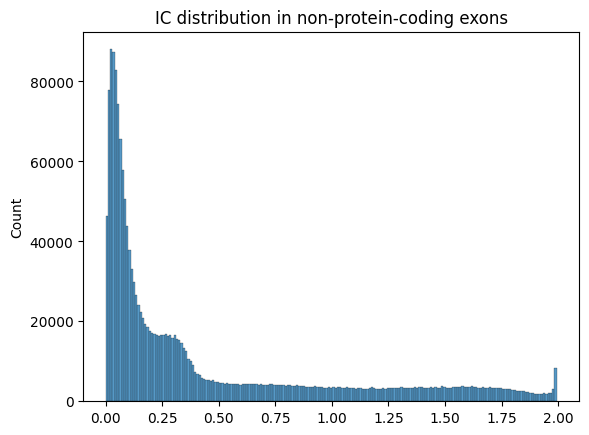

In [61]:
ax = sns.histplot(np_exon_ics)

ax.set_title("IC distribution in non-protein-coding exons")

## rRNA exons

In [62]:
rrna_ics = get_feature_ics(db, ic, "exon", "rRNA")

In [63]:
rrna_ics.mean()

np.float32(1.9868686)

In [64]:
rrna_ics.shape

(608,)

<Axes: >

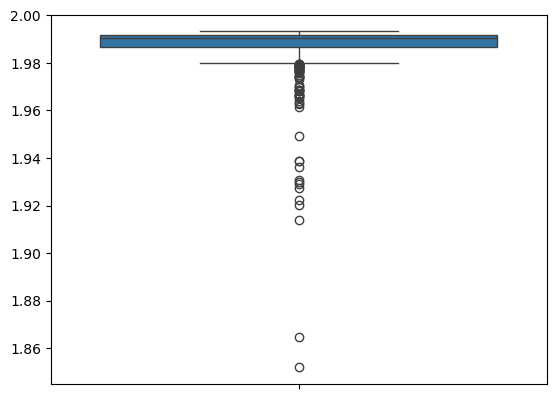

In [65]:
sns.boxplot(rrna_ics)

Text(0.5, 0, 'Information content')

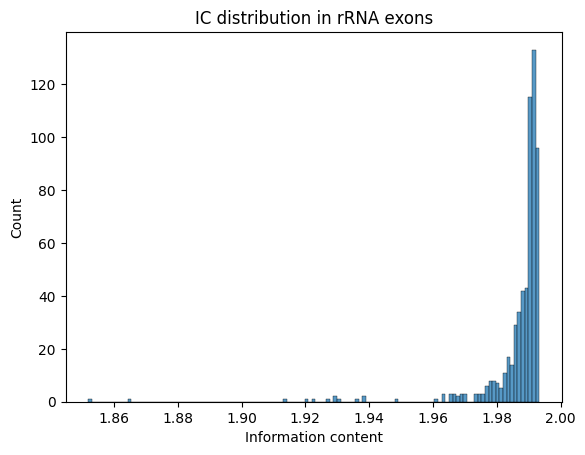

In [91]:
ax = sns.histplot(rrna_ics)
ax.set_title("IC distribution in rRNA exons")
ax.set_xlabel("Information content")

In [67]:
rrna_means = get_feature_means(db, ic, "exon", "rRNA")

In [68]:
rrna_means.shape

(4,)

## lncRNA!!!!!!

In [69]:
lnc_ics = get_feature_ics(db, ic, "exon", "lncRNA")

In [70]:
lnc_ics.mean()

np.float32(0.41283125)

In [71]:
lnc_ics.shape

(1579386,)

<Axes: >

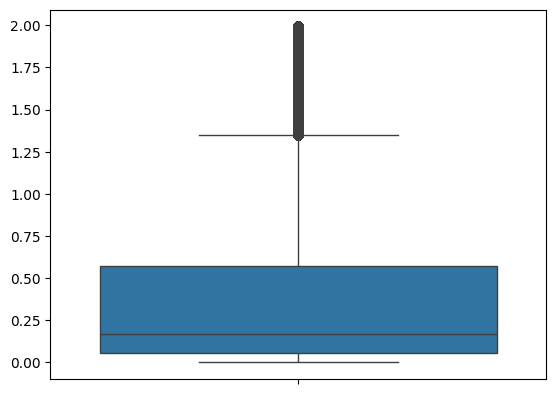

In [72]:
sns.boxplot(lnc_ics)

Text(0.5, 0, 'Information content')

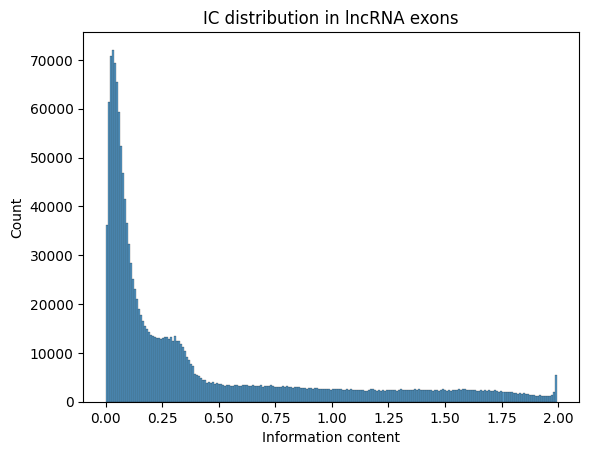

In [92]:
ax = sns.histplot(lnc_ics)

ax.set_title("IC distribution in lncRNA exons")
ax.set_xlabel("Information content")

In [74]:
lnc_means = get_feature_means(db, ic, "exon", "lncRNA")

In [75]:
lnc_means.shape

(4690,)

<Axes: >

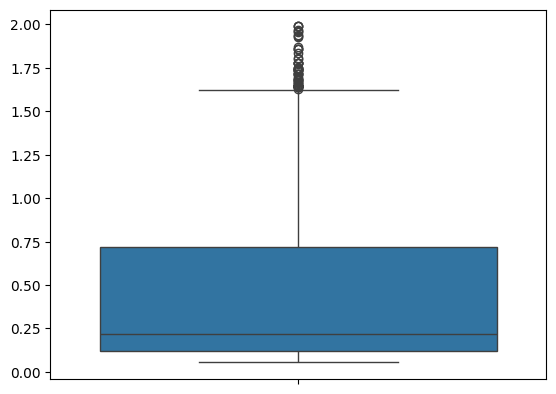

In [76]:
sns.boxplot(lnc_means)

<Axes: ylabel='Count'>

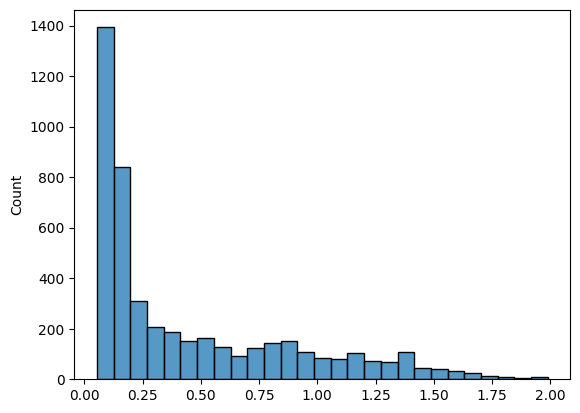

In [77]:
sns.histplot(lnc_means)

## All introns

In [78]:
def get_intron_ics(gff_db, ics, gene_type=None, offset=4169728):
    intron_ranges = []
    
    for intron in gff_db.create_introns():
        if gene_type is not None and gene_type not in intron["gene_type"]:
            continue
        intron_ranges.append((intron.start - offset, intron.end - offset))
    
    intron_ics = []
    
    for intron in intron_ranges:
        intron_ic = ic[intron[0]:intron[1]]
        intron_ics.append(intron_ic)
    
    intron_ic_arr = np.concatenate(intron_ics)

    return intron_ic_arr

In [79]:
intron_ics = get_intron_ics(db, ic)

In [80]:
intron_ics.mean()

np.float32(0.4886624)

<Axes: >

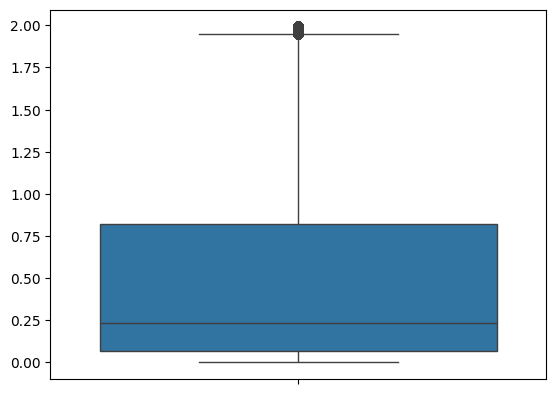

In [81]:
sns.boxplot(intron_ics)

<Axes: ylabel='Count'>

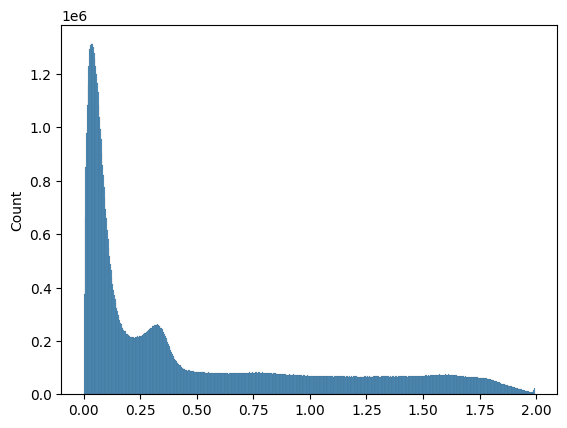

In [82]:
sns.histplot(intron_ics)

## Introns in protein-coding genes

In [83]:
pc_intron_ics = get_intron_ics(db, ic, "protein_coding")

In [84]:
pc_intron_ics.mean()

np.float32(0.46431708)

<Axes: >

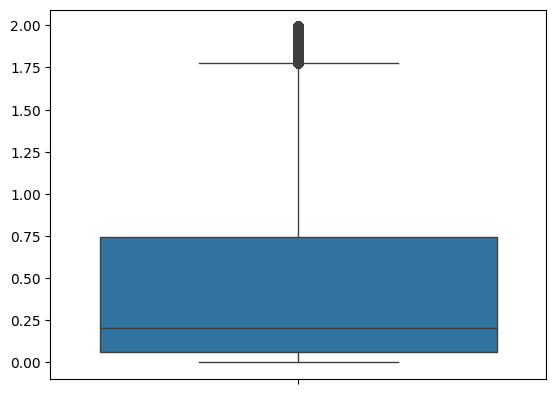

In [85]:
sns.boxplot(pc_intron_ics)

<Axes: ylabel='Count'>

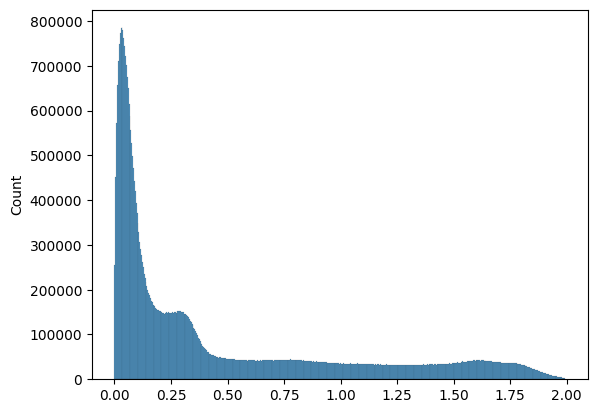

In [86]:
sns.histplot(pc_intron_ics)

## Intergenic

In [87]:
intergenic = db.interfeatures(db.merge(db.features_of_type("gene", order_by=('seqid', 'start'))))

In [88]:
inter_ranges = []

for inter in intergenic:
    inter_ranges.append((inter.start - offset, inter.end - offset))

inter_ics = []

for inter in inter_ranges:
    inter_ic = ic[inter[0]:inter[1]]
    inter_ics.append(inter_ic)

inter_ic_arr = np.concatenate(inter_ics)

NameError: name 'offset' is not defined

In [ ]:
inter_ic_arr.